<a href="https://colab.research.google.com/github/iremozdemi/MLLM-VR-MA-TSP-Agent-Study/blob/main/Repair_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 from google.colab import drive
 drive.mount('/content/drive')

Mounted at /content/drive


--- SAF LLM + BAŞLANGIÇ ÇÖZÜMÜ VE TAMİR SÜRECİ BAŞLATILIYOR ---
✅ JSON dosyasından 76 şehir koordinatı başarıyla ayıklandı.

🚀 [Deneme 1/5] Başlangıç Çözümü Ajanı tetikleniyor...
⚠️ 7 nokta eksik kaldı. Tamir Ajanı devreye giriyor...
🔧 [Gelişmiş Tamir Ajanı] Eksik noktalar sisteme entegre ediliyor: [2, 37, 69, 48, 20, 24, 61]
✅ BAŞARILI: Başlangıç Çözümü ve Tamir kombinasyonuyla %100 geçerli tam tur elde edildi!

Hesaplanan Rota Sırası: [0, 70, 69, 60, 71, 37, 20, 36, 47, 21, 61, 74, 28, 62, 73, 2, 33, 1, 43, 42, 64, 41, 22, 24, 56, 23, 49, 16, 63, 3, 44, 32, 9, 50, 18, 55, 25, 31, 39, 72, 58, 10, 38, 65, 11, 66, 59, 54, 19, 14, 53, 7, 35, 8, 46, 34, 52, 27, 13, 57, 15, 5, 29, 48, 45, 30, 4, 75, 68, 6, 51, 17, 26, 67, 40, 12, 0]
Uğranan Toplam Nokta Sayısı: 76
Hesaplanan Toplam Mesafe (Öklid): 715.27


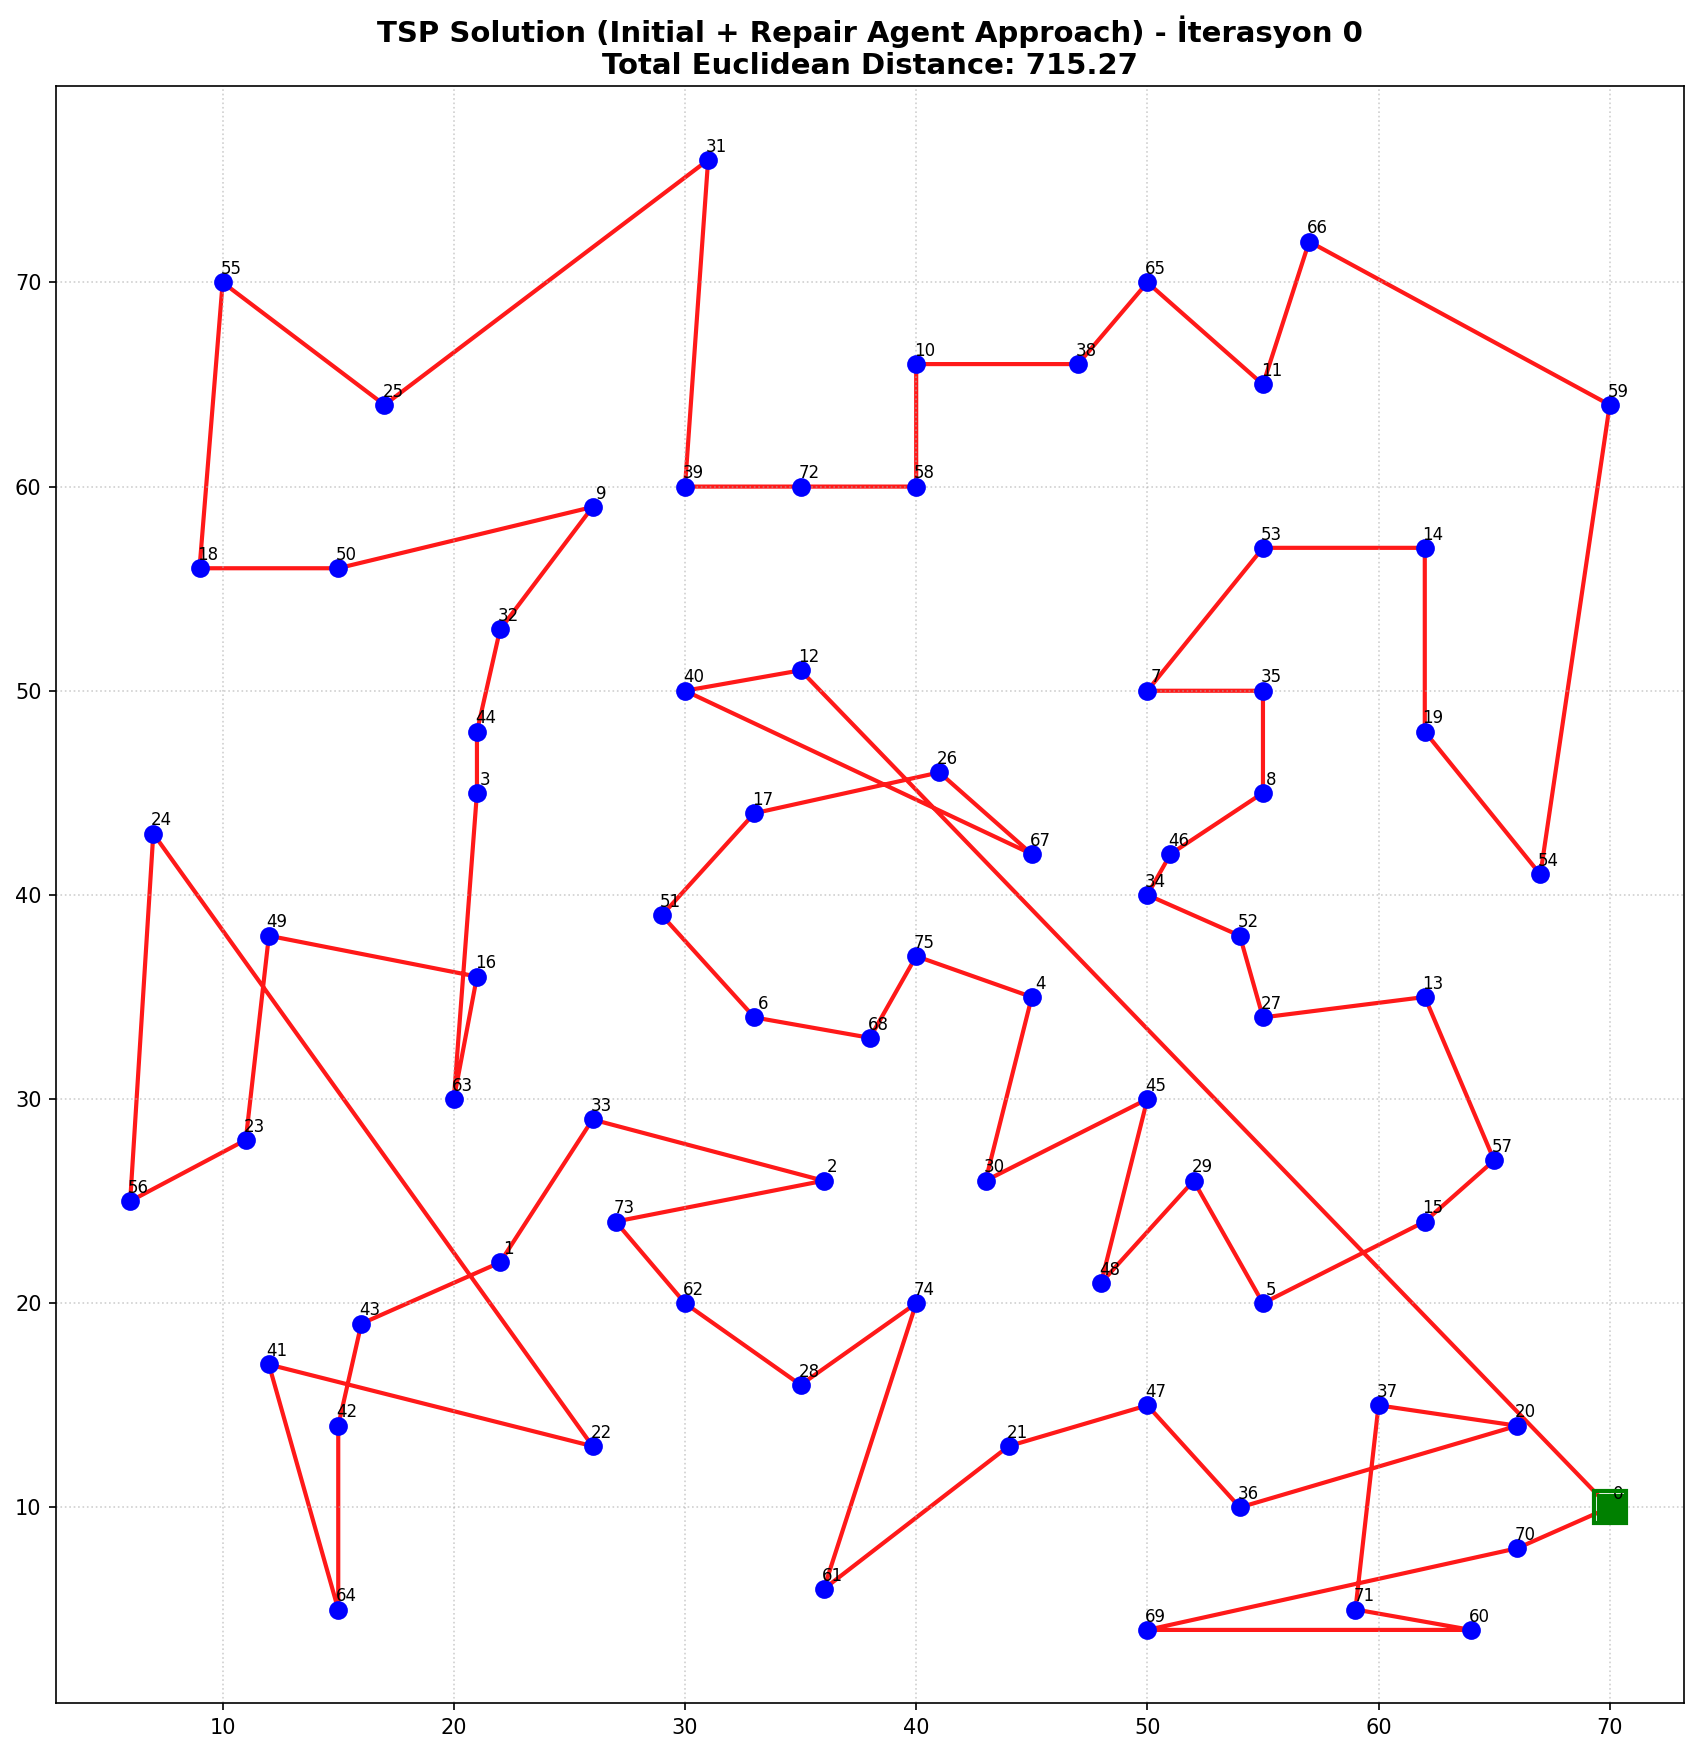

✅ ROTA GÖRSELİ BAŞARIYLA OLUŞTURULDU.

🚀 JSON ÇIKTISI BAŞARIYLA YAZILDI: /content/drive/MyDrive/76 nokta/json_outputs/initial_route_output.json

--- İŞLEM TAMAMLANDI - SÜRE: 223.10 saniye ---


In [ ]:
# -*- coding: utf-8 -*-
"""
# tsp_pure_llm_with_repair_solver.py - KÜMELEMESİZ, BAŞLANGIÇ VE TAMİR AJANLI YENİ SOLVER
"""
import matplotlib
matplotlib.use('Agg') # Kilitlenmeleri önlemek için arka plan çizim motoru
import matplotlib.pyplot as plt
import json
import numpy as np
import os
import io
import time
from google import genai
from google.genai import types
from pydantic import BaseModel, Field
from typing import List
from IPython.display import display, Image

# =================================================================
# --- API YAPILANDIRMASI ve SABİTLER ---
# =================================================================

try:
    client = genai.Client(api_key="Your API KEY")
except Exception as e:
    print(f"HATA: Gemini API istemcisi başlatılamadı: {e}")
    exit()


# =================================================================
# --- STRUCTURED OUTPUTS (YAPILANDIRILMIŞ ÇIKTI ŞEMALARI) ---
# =================================================================

class InitialRouteResponse(BaseModel):
    initial_route: List[int] = Field(
        description="The sequence of node indices attempting to visit all locations, starting and ending at the depot."
    )

class RepairedRouteResponse(BaseModel):
    repaired_route: List[int] = Field(
        description="The complete and fixed route containing ALL required nodes exactly once, starting and ending at the depot."
    )

# =================================================================
# --- FONKSİYONLAR ---
# =================================================================

def calculate_total_euclidean_distance(cities, route_list):
    """Verilen rota listesi için toplam ÖKLİD (Düz Çizgi) mesafesini hesaplar."""
    if not route_list or len(route_list) < 2:
        return float('inf')

    temp_route_list = list(route_list)
    if temp_route_list[0] != temp_route_list[-1]:
        temp_route_list.append(temp_route_list[0])

    route_coords = cities[temp_route_list]
    total_distance = 0.0
    for i in range(len(route_coords) - 1):
        p1 = route_coords[i]
        p2 = route_coords[i+1]
        total_distance += np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)
    return total_distance


def generate_and_encode_image(points, title_suffix="Global Map", depot_index=0):
    """Görsel kalitesi artırılmış saf LLM görsel besleme fonksiyonu."""
    plt.close('all')
    fig, ax = plt.subplots(figsize=(16, 16), dpi=150)

    indices_to_plot = list(range(len(points)))
    non_depot_indices = [int(i) for i in indices_to_plot if i != depot_index]

    # Düğümler Mavi, Depo Yeşil Kare
    ax.scatter(points[non_depot_indices, 0], points[non_depot_indices, 1], color='blue', s=60, zorder=2)
    ax.scatter(points[depot_index, 0], points[depot_index, 1], color='green', marker='s', s=200, zorder=3)

    for i in indices_to_plot:
        point = points[int(i)]
        ax.annotate(
            str(i), (point[0], point[1]),
            textcoords="offset points", xytext=(3, 3),
            ha='center', fontsize=8, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.15", fc="white", edgecolor="gray", alpha=0.7, linewidth=0.5)
        )

    ax.set_title(f"TSP Node Map - {title_suffix} (Nodes: {len(points)})", fontsize=16, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)

    ax.set_xlim(points[:, 0].min() - 5, points[:, 0].max() + 5)
    ax.set_ylim(points[:, 1].min() - 5, points[:, 1].max() + 5)

    img_buffer = io.BytesIO()
    plt.savefig(img_buffer, format='png', bbox_inches='tight', pad_inches=0.1)
    plt.close(fig)
    img_buffer.seek(0)
    return img_buffer.read()


def solve_initial_route_with_llm(image_bytes, points):
    """BAŞLANGIÇ ÇÖZÜMÜ AJANI: Tüm noktaları tek seferde harita ve koordinat matrisiyle çözmeye çalışır."""
    all_nodes = [int(i) for i in range(len(points))]
    node_coords = {int(idx): points[int(idx)].tolist() for idx in all_nodes}

    prompt = f"""
    ROLE & TASK:
    You are an expert operations research algorithm. Your task is to solve a Traveling Salesman Problem (TSP) by finding the shortest continuous geometric tour.
    You must propose an initial logical sequence that visits the nodes efficiently based on their spatial positions.

    MANDATORY NODES TO VISIT:
    {all_nodes}

    EXACT COORDINATES FOR REFERENCE [X, Y]:
    {json.dumps(node_coords)}

    CRITICAL CONSTRAINTS:
    1. Your output MUST start at node {depot_index} and end at node {depot_index}.
    2. Try to include every single node index exactly once in between.
    3. Sequence them smoothly to trace a clear geometric path, avoiding long criss-crossing lines.
    """

    try:
        response = client.models.generate_content(
            model='gemini-2.5-flash',
            contents=[types.Part.from_bytes(data=image_bytes, mime_type='image/png'), prompt],
            config=types.GenerateContentConfig(
                response_mime_type="application/json",
                response_schema=InitialRouteResponse,
                temperature=0.1
            )
        )
        res_json = json.loads(response.text.strip())
        return [int(x) for x in res_json.get("initial_route", [])]
    except Exception as e:
        print(f"⚠️ [Başlangıç Çözümü] API Hatası: {e}")
        return []


def repair_route_with_llm_enhanced(image_bytes, incomplete_route, missing_nodes, points, expected_length):
    """TAMİR AJANI: İlk ajanın gözünden kaçan veya eksik bıraktığı noktaları akıllıca aralara yerleştirir."""
    clean_missing_nodes = [int(x) for x in missing_nodes]
    clean_incomplete_route = [int(x) for x in incomplete_route]
    print(f"🔧 [Gelişmiş Tamir Ajanı] Eksik noktalar sisteme entegre ediliyor: {clean_missing_nodes}")

    missing_coords = {int(node): points[int(node)].tolist() for node in clean_missing_nodes}

    repair_prompt = f"""
    You are optimizing a Traveling Salesman Problem route.
    The initial solver generated a tour, but some specific nodes were missed. We must achieve a perfect single valid tour.

    CURRENT INCOMPLETE ROUTE:
    {clean_incomplete_route}

    MISSING NODES THAT MUST BE INTEGRATED:
    {clean_missing_nodes}

    COORDINATES OF THE MISSING NODES [X, Y]:
    {json.dumps(missing_coords)}

    TASK:
    Insert the missing nodes into the current incomplete route at the most mathematically and visually appropriate positions (between the closest existing neighbors) using both the map image and numerical coordinates.

    CRITICAL CONSTRAINTS:
    1. The final list length MUST be exactly {expected_length}.
    2. The route MUST start and end at node {depot_index}.
    3. ALL missing nodes must be integrated. Every node from 0 to {len(points)-1} must appear exactly once (except depot at start and end).
    """

    try:
        response = client.models.generate_content(
            model='gemini-2.5-flash',
            contents=[types.Part.from_bytes(data=image_bytes, mime_type='image/png'), repair_prompt],
            config=types.GenerateContentConfig(
                response_mime_type="application/json",
                response_schema=RepairedRouteResponse,
                temperature=0.1
            )
        )
        res_json = json.loads(response.text.strip())
        return [int(x) for x in res_json.get("repaired_route", [])]
    except Exception as e:
        print(f"⚠️ Gelişmiş tamir denemesi başarısız oldu: {e}")
        return None


def get_gemini_optimal_route_pure_llm(image_bytes, cities, max_retries=5):
    """Ana yönetim akışı: Başlangıç Çözümü ve Tamir Ajanlarını koordine eder."""
    all_indices = set(range(len(cities)))
    expected_length = len(cities) + 1

    for attempt in range(1, max_retries + 1):
        print(f"\n🚀 [Deneme {attempt}/{max_retries}] Başlangıç Çözümü Ajanı tetikleniyor...")

        # 1. Adım: Başlangıç Çözümü Ajanı Çalışır
        discovered_route = solve_initial_route_with_llm(image_bytes, cities)

        if not discovered_route:
            print("⚠️ Başlangıç rotası boş döndü. Yeniden deneniyor...")
            continue

        # Validasyon ve Eksik Analizi
        missing_nodes = all_indices - set(discovered_route)

        # 2. Adım: Eksik Varsa Tamir Ajanı Tetiklenir
        if missing_nodes:
            print(f"⚠️ {len(missing_nodes)} nokta eksik kaldı. Tamir Ajanı devreye giriyor...")
            repaired = repair_route_with_llm_enhanced(image_bytes, discovered_route, missing_nodes, cities, expected_length)
            if repaired:
                discovered_route = repaired
                missing_nodes = all_indices - set(discovered_route)

        # 3. Adım: Nihai Rota Kontrolleri
        if missing_nodes:
            print(f"⚠️ Geçersiz Rota: {len(missing_nodes)} adet nokta hala eksik. Yeniden deneniyor...")
            continue

        if len(discovered_route) != expected_length:
            print(f"⚠️ Rota uzunluğu hatalı (Mevcut: {len(discovered_route)}, Olması Gereken: {expected_length}). Yeniden deneniyor...")
            continue

        if discovered_route[0] != depot_index or discovered_route[-1] != depot_index:
            print(f"⚠️ Rota depoda ({depot_index}) başlayıp bitmiyor. Yeniden deneniyor...")
            continue

        print("✅ BAŞARILI: Başlangıç Çözümü ve Tamir kombinasyonuyla %100 geçerli tam tur elde edildi!")
        return discovered_route

    return None


def visualize_route(cities, route_list, distance, iteration_info, filename, depot_index):
    """Nihai rotayı kırmızı çizgileriyle birlikte düzgünce çizer ve diske kaydeder."""
    try:
        plt.close('all')
        fig, ax = plt.subplots(figsize=(14, 14), dpi=150)

        temp_route_list = [int(x) for x in route_list]
        if temp_route_list[0] != temp_route_list[-1]:
            temp_route_list.append(temp_route_list[0])

        route_coords = cities[temp_route_list]
        # Kırmızı Rota Çizgisi
        ax.plot(route_coords[:, 0], route_coords[:, 1], 'r-', linewidth=2, alpha=0.9, zorder=1, label='ÖKLİD Rotası')

        # Düğümler Mavi, Depo Yeşil Kare Çizimi
        for i, (x, y) in enumerate(cities):
            color = 'blue' if i != depot_index else 'green'
            marker = 'o' if i != depot_index else 's'
            sizes = 8 if i != depot_index else 12
            ax.plot(x, y, marker, color=color, markersize=sizes, zorder=2)
            ax.annotate(str(i), (x, y), textcoords="offset points", xytext=(4, 4), ha='center', fontsize=8)

        ax.plot(cities[depot_index, 0], cities[depot_index, 1], 's', color='green', markersize=15, fillstyle='none', markeredgewidth=2, zorder=4)

        title = (f"TSP Solution (Initial + Repair Agent Approach) - {iteration_info}\n"
                 f"Total Euclidean Distance: {distance:.2f}")

        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.grid(True, linestyle=':', alpha=0.6)

        os.makedirs(os.path.dirname(filename), exist_ok=True)
        plt.savefig(filename, bbox_inches='tight')
        plt.close(fig)

        display(Image(filename=filename))
        print(f"✅ ROTA GÖRSELİ BAŞARIYLA OLUŞTURULDU.")
    except Exception as e:
        print(f"HATA: Görselleştirme aşamasında sorun çıktı: {e}")

# =================================================================
# --- ANA AKIŞ ---
# =================================================================

total_start_time = time.time()
print("--- SAF LLM + BAŞLANGIÇ ÇÖZÜMÜ VE TAMİR SÜRECİ BAŞLATILIYOR ---")

# 1. Veri Yükleme
try:
    with open(json_filename, 'r', encoding='utf-8') as f:
        json_content = json.load(f)

    extracted_nodes = [[node[0], node[1]] for node in json_content]
    cities = np.array(extracted_nodes, dtype=float)

    new_depot_coords = np.array([70.0, 10.0], dtype=float)
    if cities.shape[0] > depot_index:
        cities[depot_index] = new_depot_coords
    print(f"✅ JSON dosyasından {len(cities)} şehir koordinatı başarıyla ayıklandı.")
except Exception as e:
    print(f"HATA: JSON okunamadı: {e}")
    exit()

# 2. Ana Görsel Hazırlama (Ajanlara Gönderilecek Global Harita)
image_bytes = generate_and_encode_image(cities, title_suffix="Global Map", depot_index=depot_index)

# 3. İki Aşamalı LLM Rotalama Süreci (Initial Solver + Repair Agent)
route_list = get_gemini_optimal_route_pure_llm(image_bytes, cities)

# 4. Kesin Kontrol ve Durdurma
if not route_list:
    print("\n❌ [KRİTİK HATA] Gemini ajanları geçerli bir tam rota üretemedi.")
    exit()

# 5. Mesafe Hesaplama ve Çizim
total_euclidean_distance = calculate_total_euclidean_distance(cities, route_list)
print(f"\nHesaplanan Rota Sırası: {route_list}")
print(f"Uğranan Toplam Nokta Sayısı: {len(set(route_list))}")
print(f"Hesaplanan Toplam Mesafe (Öklid): {total_euclidean_distance:.2f}")

visualize_route(cities, route_list, total_euclidean_distance, "İterasyon 0", output_plot_filename, depot_index)

# 6. JSON Çıktısı Üretme
output_data = {
    "cities_coordinates": cities.tolist(),
    "initial_route": route_list,
    "initial_distance_EUCLIDEAN": total_euclidean_distance,
    "depot_index": depot_index,
    "current_image_path": output_plot_filename
}

try:
    os.makedirs(os.path.dirname(initial_output_json), exist_ok=True)
    with open(initial_output_json, 'w', encoding='utf-8') as f:
        json.dump(output_data, f, indent=4)
    print(f"\n🚀 JSON ÇIKTISI BAŞARIYLA YAZILDI: {initial_output_json}")
except Exception as e:
    print(f"HATA: Veri kaydedilemedi: {e}")

print(f"\n--- İŞLEM TAMAMLANDI - SÜRE: {time.time() - total_start_time:.2f} saniye ---")